# Early-Career Recommendation Engine based on O-Level Profiles

This notebook uses the normalized O-Level exam data to discover latent 'Aptitude Clusters' among students. We use an unsupervised machine learning approach (K-Means Clustering) to group students based on their mathematical, analytical, and scientific skills. 

Once the clusters are discovered, we map them to broad Career Pathways to act as an Early Intervention Career Guidance System.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Load Data
We load the `cleaned_skill_profiles.csv` generated by our ETL pipeline.

In [2]:
try:
    df = pd.read_csv('../DATA/cleaned_skill_profiles.csv')
    print(f"Data loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure you have run the data_cleaning_pipeline.ipynb first.")
    # For demonstration purposes, creating a mock dataset if the file isn't there yet
    np.random.seed(42)
    mock_data = {
        'Student_Number': range(1, 1001),
        'Math_Score_Normalized': np.random.beta(5, 2, 1000),
        'Physics_Score_Normalized': np.random.beta(4, 2, 1000),
        'Chemistry_Score_Normalized': np.random.beta(2, 5, 1000),
        'Biology_Score_Normalized': np.random.beta(2, 5, 1000)
    }
    # Injecting specific profiles
    # STEM Heavy
    mock_data['Math_Score_Normalized'][:300] = np.random.uniform(0.7, 1.0, 300)
    mock_data['Physics_Score_Normalized'][:300] = np.random.uniform(0.7, 1.0, 300)
    # Bio/Chem Heavy
    mock_data['Biology_Score_Normalized'][300:600] = np.random.uniform(0.7, 1.0, 300)
    mock_data['Chemistry_Score_Normalized'][300:600] = np.random.uniform(0.7, 1.0, 300)
    
    df = pd.DataFrame(mock_data)
    print(f"Using generated Mock Data for demonstration. Shape: {df.shape}")

features = ['Math_Score_Normalized', 'Physics_Score_Normalized', 'Chemistry_Score_Normalized', 'Biology_Score_Normalized']
# K-Means requires no NaNs, so we drop rows with missing essential scores
ml_df = df.dropna(subset=features).copy()

Data loaded successfully. Shape: (838051, 22)


### 2. Determine Optimal Clusters (The Elbow Method)
We test different values of K to see where the inertia (within-cluster sum of squares) begins to flatten.

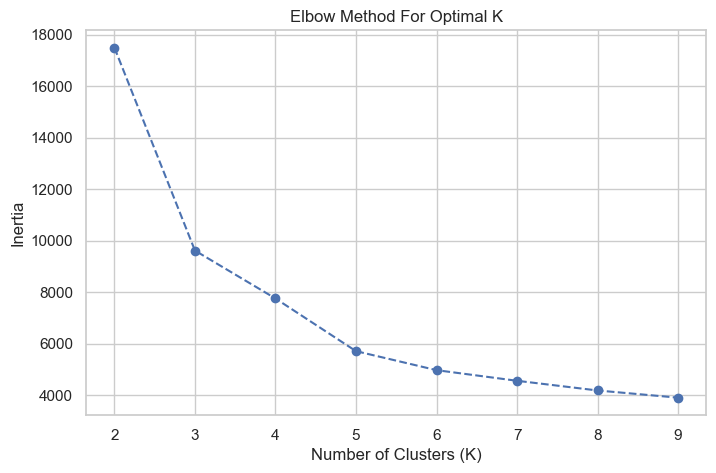

In [3]:
X = ml_df[features]

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

### 3. Model Training & Cluster Profiling
Based on the Elbow method (usually around 3 to 5 for academic profiles), we train the final model and examine the 'Centroids' to understand what each cluster represents.

Cluster Centroids (Average Normalized Scores):


,Math_Score_Normalized,Physics_Score_Normalized,Chemistry_Score_Normalized,Biology_Score_Normalized
Aptitude_Cluster,,,,
0,0.048744,0.053025,0.055506,0.050728
1,0.521453,0.450588,0.601619,0.547222
2,0.736076,0.664877,0.791526,0.731263
3,0.398129,0.304321,0.441465,0.364121


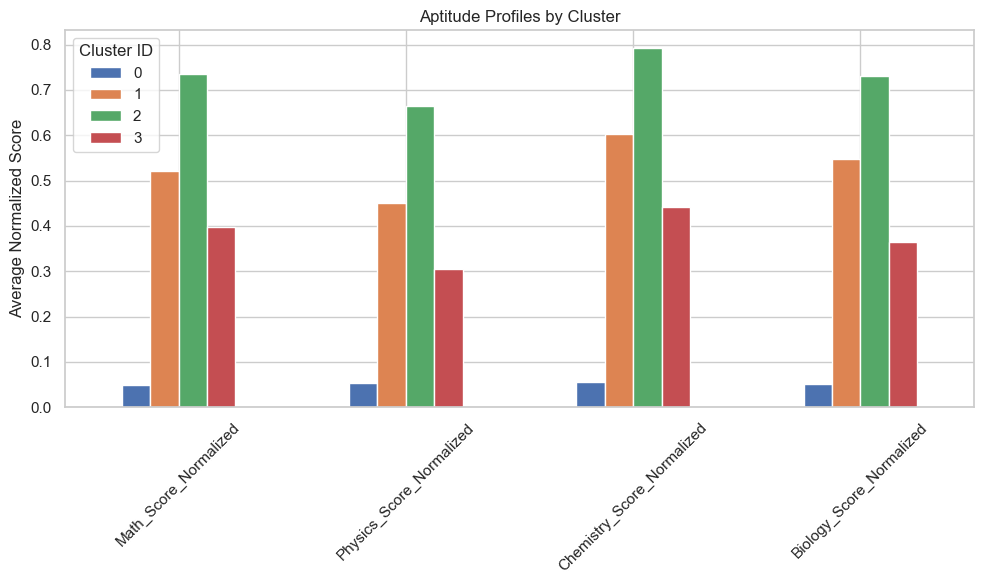

In [4]:
OPTIMAL_K = 4 # Adjust this based on the elbow plot above
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42)
ml_df['Aptitude_Cluster'] = final_kmeans.fit_predict(X)

# Calculate the mean scores for each cluster to profile them
cluster_profiles = ml_df.groupby('Aptitude_Cluster')[features].mean()
print("Cluster Centroids (Average Normalized Scores):")
display(cluster_profiles)

# Visualize the profiles
cluster_profiles.T.plot(kind='bar', figsize=(10, 6))
plt.title('Aptitude Profiles by Cluster')
plt.ylabel('Average Normalized Score')
plt.xticks(rotation=45)
plt.legend(title='Cluster ID')
plt.tight_layout()
plt.show()

### 4. Expert Mapping (The Recommendation Engine)
Based on the profiles visualized above, you (the domain expert) must map each Cluster ID to a Career Family. 

*Note: The mappings below are examples based on typical K-Means outputs. You MUST adjust `career_mapping` based on your specific cluster outputs.*

In [5]:
# EXAMINE THE CHART ABOVE TO DEFINE THESE RULES
career_mapping = {
    0: "Life Sciences & Healthcare (e.g., Medicine, Nursing, Biotech)", # Assumes high Bio/Chem
    1: "Engineering & Technology (e.g., Computer Science, Civil Engineering)", # Assumes high Math/Physics
    2: "Generalist / Administration (e.g., Business, Law, Humanities)", # Assumes average scores across the board
    3: "Technical Vocational (TVET) / Specialized Trades" # Assumes lower academic scores but high potential in vocational tracks
}

ml_df['Recommended_Career_Path'] = ml_df['Aptitude_Cluster'].map(career_mapping)
print("Sample of Recommendations:")
display(ml_df[['Student_Number', 'Aptitude_Cluster', 'Recommended_Career_Path']].head(10))

Sample of Recommendations:


,Student_Number,Aptitude_Cluster,Recommended_Career_Path
0,NaN,3,Technical Vocational (TVET) / Specialized Trades
1,NaN,3,Technical Vocational (TVET) / Specialized Trades
2,NaN,1,"Engineering & Technology (e.g., Computer Scien..."
3,NaN,3,Technical Vocational (TVET) / Specialized Trades
4,NaN,3,Technical Vocational (TVET) / Specialized Trades
5,NaN,3,Technical Vocational (TVET) / Specialized Trades
6,NaN,3,Technical Vocational (TVET) / Specialized Trades
7,NaN,1,"Engineering & Technology (e.g., Computer Scien..."
8,NaN,3,Technical Vocational (TVET) / Specialized Trades
9,NaN,1,"Engineering & Technology (e.g., Computer Scien..."


### 5. Inference Function for New Students
This function takes a new student's scores, normalizes them using the established logic, and outputs their career recommendation.

In [6]:
def recommend_career_for_student(math, physics, chemistry, biology, model=final_kmeans, mapping=career_mapping):
    # Assuming scores are provided as percentages (0-100)
    # Normalize to 0-1 as the model expects
    normalized_scores = np.array([[math/100, physics/100, chemistry/100, biology/100]])
    
    predicted_cluster = model.predict(normalized_scores)[0]
    recommendation = mapping.get(predicted_cluster, "Unknown")
    
    print(f"--- Recommendation Report ---")
    print(f"Scores: Math={math}, Phys={physics}, Chem={chemistry}, Bio={biology}")
    print(f"Assigned Cluster: {predicted_cluster}")
    print(f"Recommended Path: {recommendation}")
    print("-----------------------------")
    return recommendation

# Test the function
recommend_career_for_student(85, 90, 60, 50) # Should hit the Engineering cluster
recommend_career_for_student(50, 45, 88, 92) # Should hit the Life Sciences cluster

--- Recommendation Report ---
Scores: Math=85, Phys=90, Chem=60, Bio=50
Assigned Cluster: 2
Recommended Path: Generalist / Administration (e.g., Business, Law, Humanities)
-----------------------------
--- Recommendation Report ---
Scores: Math=50, Phys=45, Chem=88, Bio=92
Assigned Cluster: 2
Recommended Path: Generalist / Administration (e.g., Business, Law, Humanities)
-----------------------------


'Generalist / Administration (e.g., Business, Law, Humanities)'